In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [45]:
df = pd.read_csv('/home/varsha/PracticePython/100DaysOfMl/ML06_Pipelines/Titanic_Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [46]:
df['family']= df['SibSp'] + df['Parch']
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [47]:
df = df.loc[:, ['Age', 'Fare', 'family','Survived']]
df.head()

,Age,Fare,family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [48]:
df.isnull().sum()

Age         177
Fare          0
family        0
Survived      0
dtype: int64

In [49]:
df.isnull().mean()

Age         0.198653
Fare        0.000000
family      0.000000
Survived    0.000000
dtype: float64

In [50]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
df.shape

(891, 4)

In [52]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((712, 3), (712,), (179, 3), (179,))

In [53]:
X_train.head()

,Age,Fare,family
331,45.5,28.5000,0
733,23.0,13.0000,0
382,32.0,7.9250,0
704,26.0,7.8542,1
813,6.0,31.2750,6


In [54]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [55]:
X_train.head()

,Age,Fare,family,Age_imputed
331,45.5,28.5000,0,45.5
733,23.0,13.0000,0,23.0
382,32.0,7.9250,0,32.0
704,26.0,7.8542,1,26.0
813,6.0,31.2750,6,6.0


In [56]:
X_test.head()

,Age,Fare,family,Age_imputed
709,NaN,15.2458,2,NaN
439,31.0,10.5000,0,31.0
840,20.0,7.9250,0,20.0
720,6.0,33.0000,1,6.0
39,14.0,11.2417,1,14.0


In [57]:
X_train['Age_imputed'][X_train['Age'].isnull()] = X_train['Age'].sample(X_train['Age'].isnull().sum()).values

/tmp/ipykernel_6372/1250675219.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age'].isnull()] = X_train['Age'].sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_6372/1250675219.py:1: SettingWith

In [58]:
X_train.tail(8)

,Age,Fare,family,Age_imputed
20,35.0,26.0000,0,35.0
700,18.0,227.5250,1,18.0
71,16.0,46.9000,7,16.0
106,21.0,7.6500,0,21.0
270,NaN,31.0000,0,35.0
860,41.0,14.1083,2,41.0
435,14.0,120.0000,3,14.0
102,21.0,77.2875,1,21.0


In [59]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([26.  , 41.  , 25.  , 35.  , 23.  , 45.  , 36.  , 19.  , 58.  ,
        1.  , 31.  , 20.  , 42.  , 64.  , 31.  , 33.  , 20.  , 27.  ,
       50.  , 33.  , 36.  , 28.  , 55.  ,  2.  , 18.  ,  1.  , 35.  ,
       22.  , 34.  , 26.  , 34.5 , 30.  , 45.  , 22.  , 30.  , 41.  ,
       24.  , 35.  , 16.  , 48.  , 43.  , 21.  , 28.  , 29.  , 26.  ,
       16.  , 34.  , 39.  , 27.  , 19.  , 18.  , 63.  , 44.  , 24.  ,
       39.  , 45.  , 29.  , 18.  , 14.  , 19.  , 50.  , 28.5 , 33.  ,
       36.  , 29.  ,  4.  , 36.  , 65.  , 33.  , 30.  , 19.  , 28.  ,
       29.  , 34.  , 20.  , 20.  , 38.  , 25.  , 14.  , 38.  , 47.  ,
       39.  , 28.  , 14.  , 21.  , 40.5 ,  0.75, 21.  , 32.  ,  3.  ,
       25.  , 20.  , 23.  , 14.5 , 26.  , 33.  , 16.  , 32.  , 52.  ,
       60.  , 22.  , 22.  , 39.  ,  3.  , 15.  , 31.  , 45.  , 44.  ,
       24.  , 31.  , 54.  , 18.  , 32.  , 38.  , 24.5 , 15.  ,  4.  ,
       44.  , 27.  , 26.  , 20.  , 27.  , 42.  , 11.  , 23.  , 31.  ,
       25.  , 50.  ,

In [60]:
X_train['Age'].isnull().sum()

np.int64(140)

"same can be done with sns:\nsns.distplot(X_train['Age'],label='Original',hist=False)\nsns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)\n\nplt.legend()\nplt.show()"

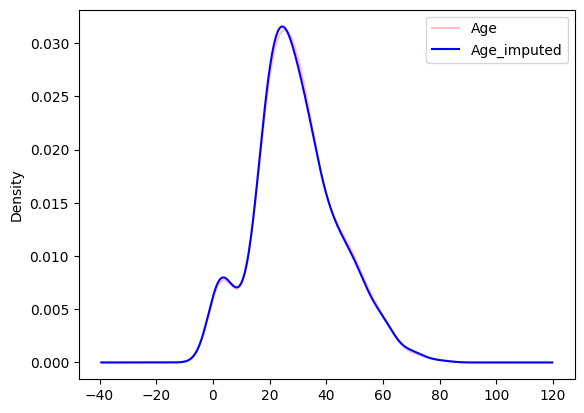

<Figure size 640x480 with 0 Axes>

In [61]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax, color='pink')

# variable imputed with the random
X_train['Age_imputed'].plot(kind='kde', ax=ax, color='blue')


# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')
fig = plt.figure()


'''same can be done with sns:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()'''

In [62]:
print('Original variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variance:  210.2517072477435
Variance after random imputation:  212.61382857653277


In [63]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2700.831981,71.580633,64.474242
Age,71.580633,210.251707,210.251707
Age_imputed,64.474242,210.251707,212.613829


<Axes: >

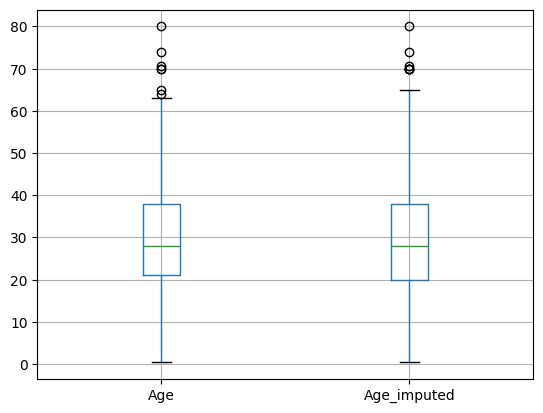

In [64]:
# check outliers
X_train[['Age', 'Age_imputed']].boxplot()

when we impute random value we must insert the same random value for the same number . let's say age is 30 and fare is 80 so it should be same for age where value is 30

In [65]:
sampled_value = X_train['Age'].dropna().sample(1, random_state=42).values[0]